# Sistemas de recomendación

In [1]:
#!pip install scikit-surprise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from surprise import Reader
from surprise import Dataset
from surprise.model_selection import cross_validate
from surprise import NormalPredictor
from surprise import KNNBasic
from surprise import KNNWithMeans
from surprise import KNNWithZScore
from surprise import KNNBaseline
from surprise import SVD
from surprise import BaselineOnly
from surprise import NMF
from surprise import SlopeOne
from surprise import CoClustering
from surprise import accuracy
from surprise.model_selection import train_test_split

In [3]:
user = pd.read_csv('demo_11_dataset/BX-Users.csv', sep=';', encoding="latin-1")
user.columns = ['userID', 'Location', 'Age']
rating = pd.read_csv('demo_11_dataset/BX-Book-Ratings.csv', sep=';', encoding="latin-1")
rating.columns = ['userID', 'ISBN', 'bookRating']
df = pd.merge(user, rating, on='userID', how='inner')
df.drop(['Location', 'Age'], axis=1, inplace=True)
df.head()

,userID,ISBN,bookRating
0,2,0195153448,0
1,7,034542252,0
2,8,0002005018,5
3,8,0060973129,0
4,8,0374157065,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   userID      1149780 non-null  int64 
 1   ISBN        1149780 non-null  object
 2   bookRating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Veamos la distribución de las valoraciones

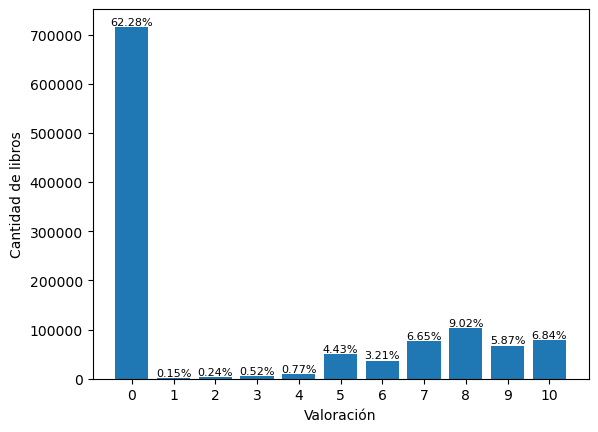

In [5]:
data = df['bookRating'].value_counts().sort_index(ascending=False)

p1 = plt.bar(data.index,data.values)

for rect1 in p1:
    height = rect1.get_height()
    plt.annotate( f"{height/data.values.sum()*100:.2f}%",(rect1.get_x() + rect1.get_width()/2, height+.05),ha="center",va="bottom",fontsize=8)

plt.xticks(np.arange(0,11,1))
plt.ylabel('Cantidad de libros')
plt.xlabel('Valoración')
plt.show()

Veamos cómo es la distribución de número de valoraciones por libro

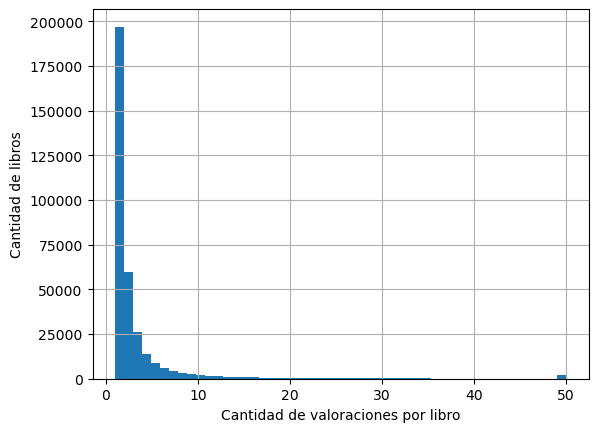

In [6]:
data = df.groupby('ISBN')['bookRating'].count()

data.clip(upper=50).hist(bins=50)
plt.xlabel('Cantidad de valoraciones por libro')
plt.ylabel('Cantidad de libros')
plt.show()

In [7]:
# Los 10 libros más votados
data.sort_values(ascending=False)[:10]

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: bookRating, dtype: int64

Ahora podemos pensar en la distribución de cantidad de valoraciones por usuario

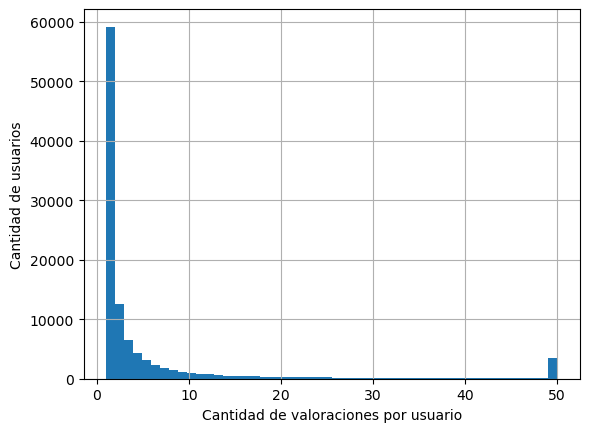

In [8]:
data = df.groupby('userID')['bookRating'].count()
data.clip(upper=50).hist(bins=50)
plt.xlabel('Cantidad de valoraciones por usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()

La mayoria de los usuarios dan menos de 10 valoraciones. Cuántas valoraciones dio el usuario más activo?

In [9]:
df

,userID,ISBN,bookRating
0,2,0195153448,0
1,7,034542252,0
2,8,0002005018,5
3,8,0060973129,0
4,8,0374157065,0
...,...,...,...
1149775,278854,0425163393,7
1149776,278854,0515087122,0
1149777,278854,0553275739,6
1149778,278854,0553578596,0


In [10]:
df.groupby('userID')['bookRating'].count().sort_values(ascending=False)[:5]

userID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
Name: bookRating, dtype: int64

Tanto el número de valoraciones por libro y el número de valoraciones por usuario tienen distribuciones que decaen exponencialmente!

Para evitar problemas de memoria, vamos a filtrar los libros y los usuarios "outlayers". 

In [11]:
min_book_ratings = 50
filter_books = df['ISBN'].value_counts() > min_book_ratings
filter_books = filter_books[filter_books].index.tolist()

min_user_ratings = 50
filter_users = df['userID'].value_counts() > min_user_ratings
filter_users = filter_users[filter_users].index.tolist()

df_new = df[(df['ISBN'].isin(filter_books)) & (df['userID'].isin(filter_users))]
print('The original data frame shape:\t{}'.format(df.shape))
print('The new data frame shape:\t{}'.format(df_new.shape))

The original data frame shape:	(1149780, 3)
The new data frame shape:	(140516, 3)


Armamos un array booleano que nos indica cuáles ISBN's cumplen con la condición lógica de al menos tener 50 ratings

In [12]:
min_book_ratings = 50
filter_books = df['ISBN'].value_counts() > min_book_ratings
filter_books

ISBN
0971880107     True
0316666343     True
0385504209     True
0060928336     True
0312195516     True
              ...  
0916211223    False
0916211231    False
0916211274    False
0916211282    False
1569661057    False
Name: count, Length: 340556, dtype: bool

Luego, nos quedamos sólo con los que los cumplen

In [13]:
filter_books = filter_books[filter_books].index.tolist()
filter_books

['0971880107',
 '0316666343',
 '0385504209',
 '0060928336',
 '0312195516',
 '044023722X',
 '0679781587',
 '0142001740',
 '067976402X',
 '0671027360',
 '0446672211',
 '059035342X',
 '0316601950',
 '0375727345',
 '044021145X',
 '0452282152',
 '0440214041',
 '0804106304',
 '0440211727',
 '0345337662',
 '0060930535',
 '0440226430',
 '0312278586',
 '0743418174',
 '0671021001',
 '0345370775',
 '0446605239',
 '0156027321',
 '0440241073',
 '0671003755',
 '0060976845',
 '1400034779',
 '0786868716',
 '0440234743',
 '0440222656',
 '0440221471',
 '0345361792',
 '0440236673',
 '0345417623',
 '0316769487',
 '0446610038',
 '0385484518',
 '0446310786',
 '044022165X',
 '0375706771',
 '0440225701',
 '0440220602',
 '0060502258',
 '0446606812',
 '0345353145',
 '044651652X',
 '0140293248',
 '0345443284',
 '0440206154',
 '0440213525',
 '006101351X',
 '0316284955',
 '0312291639',
 '0375707972',
 '0439064872',
 '0060934417',
 '0385335482',
 '0671510053',
 '0440224764',
 '0452282829',
 '0385492081',
 '06848447

In [14]:
condicion1 = (df['ISBN'].isin(filter_books))
df[condicion1]['ISBN'].value_counts()

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
              ... 
0812513711      51
0671020293      51
0670896764      51
0394281802      51
0446613053      51
Name: count, Length: 2125, dtype: int64

Hacemos lo mismo con los usuarios

In [15]:
min_user_ratings = 50
filter_users = df['userID'].value_counts() > min_user_ratings
filter_users = filter_users[filter_users].index.tolist()
condicion2 = (df['userID'].isin(filter_users))
df_new = df[(condicion2 & condicion1)]

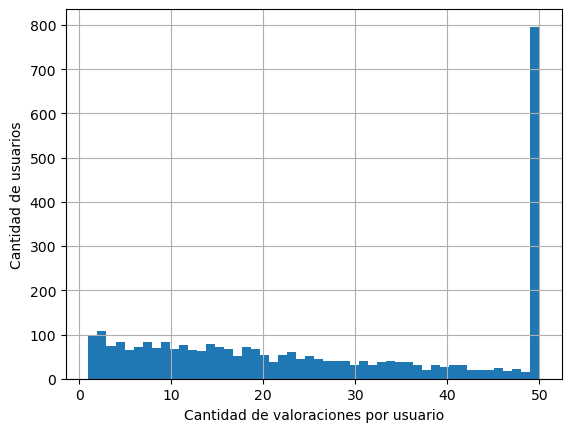

In [16]:
data = df_new.groupby('userID')['bookRating'].count()
data.clip(upper=50).hist(bins=50)
plt.xlabel('Cantidad de valoraciones por usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()

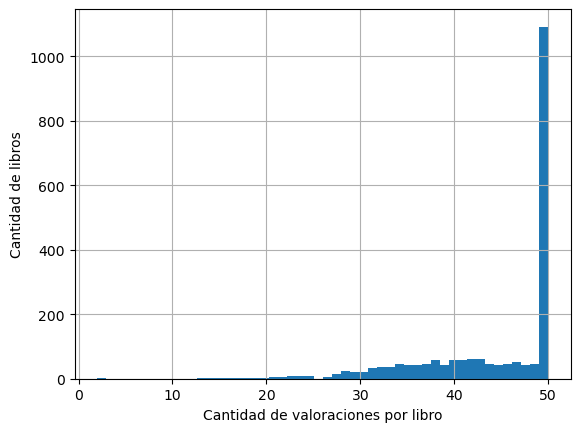

In [17]:
data = df_new.groupby('ISBN')['bookRating'].count()

data.clip(upper=50).hist(bins=50)
plt.xlabel('Cantidad de valoraciones por libro')
plt.ylabel('Cantidad de libros')
plt.show()

## Búsqueda del mejor modelo 

In [18]:
Reader?

Init signature:
Reader(
    name=None,
    line_format='user item rating',
    sep=None,
    rating_scale=(1, 5),
    skip_lines=0,
)
Docstring:     
The Reader class is used to parse a file containing ratings.

Such a file is assumed to specify only one rating per line, and each line
needs to respect the following structure: ::

    user ; item ; rating ; [timestamp]

where the order of the fields and the separator (here ';') may be
arbitrarily defined (see below).  brackets indicate that the timestamp
field is optional.

For each built-in dataset, Surprise also provides predefined readers which
are useful if you want to use a custom dataset that has the same format as
a built-in one (see the ``name`` parameter).


Args:
    name(:obj:`string`, optional): If specified, a Reader for one of the
        built-in datasets is returned and any other parameter is ignored.
        Accepted values are 'ml-100k', 'ml-1m', and 'jester'. Default
        is ``None``.
    line_format(:obj:`string`)

In [19]:
reader = Reader(rating_scale=(1, 10)) # 0 = N/A
data = Dataset.load_from_df(df_new[['userID', 'ISBN', 'bookRating']], reader)

benchmark = []
# Iterate over all algorithms
for i, algorithm in enumerate([SVD(), SlopeOne(), NMF(), NormalPredictor(), KNNBaseline(), #SVDpp
                 KNNBasic(), KNNWithMeans(), KNNWithZScore(), BaselineOnly(), CoClustering()]):
    # Perform cross validation
    print(i)
    try:
        results = cross_validate(algorithm, data, measures=['RMSE'], cv=3, verbose=False)
            # Get results & append algorithm name
        tmp = pd.DataFrame.from_dict(results).mean(axis=0)
        tmp = tmp._append(pd.Series([str(algorithm).split(' ')[0].split('.')[-1]], index=['Algorithm']))
        benchmark.append(tmp)
        print(tmp)
    except:
        continue


0
test_rmse    3.520792
fit_time     0.534572
test_time    0.185131
Algorithm         SVD
dtype: object
1
test_rmse    3.465409
fit_time     0.444028
test_time    1.879079
Algorithm    SlopeOne
dtype: object
2
test_rmse    3.840792
fit_time     1.297323
test_time    0.146888
Algorithm         NMF
dtype: object
3
test_rmse           4.585453
fit_time            0.063481
test_time            0.08634
Algorithm    NormalPredictor
dtype: object
4
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
test_rmse       3.491938
fit_time         0.42984
test_time       2.343304
Algorithm    KNNBaseline
dtype: object
5
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing

[Overview](https://www.kdnuggets.com/2017/08/recommendation-system-algorithms-overview.html) de los algoritmos

Algunos:

- NormalPredictor : $\hat{r}_{ui}$ se muestrea de una distribución gaussiana con media $\hat{\mu}$ y desvío $\hat{\sigma}^2$ obtenidos por máxima verosimilitud utilizando los datos de entrenamiento.

- [BaselineOnly](https://surprise.readthedocs.io/en/stable/prediction_algorithms.html#baseline-estimates-configuration) : $\hat{r}_{ui} = \mu + b_u + b_i$

- [kNNBasic](https://surprise.readthedocs.io/en/stable/prediction_algorithms.html#similarity-measures-configuration) : $\hat{r}_{ui} = \frac{\sum_{v \in vecinos}sim(u,v) \cdot r_{vi}}{\sum_{v \in vecinos} sim(u,v)}$

- [Matrix factorization](https://surprise.readthedocs.io/en/stable/matrix_factorization.html) : $\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u$ (si $\mu$, $b_u$ y $b_i$ son 0 se llama Probabilistic Matrix Factorization)

In [20]:
benchmark

[test_rmse    3.520792
 fit_time     0.534572
 test_time    0.185131
 Algorithm         SVD
 dtype: object,
 test_rmse    3.465409
 fit_time     0.444028
 test_time    1.879079
 Algorithm    SlopeOne
 dtype: object,
 test_rmse    3.840792
 fit_time     1.297323
 test_time    0.146888
 Algorithm         NMF
 dtype: object,
 test_rmse           4.585453
 fit_time            0.063481
 test_time            0.08634
 Algorithm    NormalPredictor
 dtype: object,
 test_rmse       3.491938
 fit_time         0.42984
 test_time       2.343304
 Algorithm    KNNBaseline
 dtype: object,
 test_rmse    3.687403
 fit_time     0.329487
 test_time    2.073208
 Algorithm    KNNBasic
 dtype: object,
 test_rmse        3.480582
 fit_time         0.356007
 test_time        2.150967
 Algorithm    KNNWithMeans
 dtype: object,
 test_rmse         3.508663
 fit_time          0.420311
 test_time         2.303961
 Algorithm    KNNWithZScore
 dtype: object,
 test_rmse        3.386248
 fit_time         0.122158
 test_

In [21]:
surprise_results = pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse')
surprise_results

,test_rmse,fit_time,test_time
Algorithm,,,
BaselineOnly,3.386248,0.122158,0.120058
SlopeOne,3.465409,0.444028,1.879079
CoClustering,3.468962,0.964690,0.224458
KNNWithMeans,3.480582,0.356007,2.150967
KNNBaseline,3.491938,0.429840,2.343304
KNNWithZScore,3.508663,0.420311,2.303961
SVD,3.520792,0.534572,0.185131
KNNBasic,3.687403,0.329487,2.073208
NMF,3.840792,1.297323,0.146888


## Selección de modelo y selección de hiperparámetros

Nos quedamos con el algoritmo `BaselineOnly()`. Además vamos a utilizar el método [Alternating Least Squares](https://sophwats.github.io/2018-04-05-gentle-als.html) para encontrar los $b_u$ y $b_i$

In [22]:
print('Using ALS')
bsl_options = {'method': 'als',
               'n_epochs': 5,
               'reg_u': 12,
               'reg_i': 5
               }
algo = BaselineOnly(bsl_options=bsl_options)
cross_validate(algo, data, measures=['RMSE'], cv=3, verbose=False)

Using ALS
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...


{'test_rmse': array([3.37456465, 3.40369956, 3.37167639]),
 'fit_time': (0.0786895751953125, 0.0665736198425293, 0.07924032211303711),
 'test_time': (0.1396026611328125, 0.07837486267089844, 0.12932682037353516)}

In [23]:
trainset, testset = train_test_split(data, test_size=0.25)
algo = BaselineOnly(bsl_options=bsl_options)
predictions = algo.fit(trainset).test(testset)

Estimating biases using als...


## Analizando los resultados

In [24]:
predictions

[Prediction(uid=80538, iid='0060976845', r_ui=7.0, est=2.9155884213714183, details={'was_impossible': False}),
 Prediction(uid=11676, iid='0425150143', r_ui=5.0, est=4.009170527077268, details={'was_impossible': False}),
 Prediction(uid=252222, iid='0375707972', r_ui=0.0, est=2.1493241191565424, details={'was_impossible': False}),
 Prediction(uid=217318, iid='0515119644', r_ui=5.0, est=3.9841599066675815, details={'was_impossible': False}),
 Prediction(uid=30533, iid='0515136379', r_ui=0.0, est=2.3790539660057664, details={'was_impossible': False}),
 Prediction(uid=36836, iid='0394742117', r_ui=0.0, est=1, details={'was_impossible': False}),
 Prediction(uid=110373, iid='0312195516', r_ui=0.0, est=4.805381257886607, details={'was_impossible': False}),
 Prediction(uid=125039, iid='0440234743', r_ui=0.0, est=1.4895109876562358, details={'was_impossible': False}),
 Prediction(uid=56307, iid='0446613266', r_ui=0.0, est=3.0953472908313215, details={'was_impossible': False}),
 Prediction(uid=

In [25]:
accuracy.rmse(predictions)

RMSE: 3.3617


3.361674676817385

In [26]:
trainset = algo.trainset
print(algo.__class__.__name__)

BaselineOnly


In [27]:
def get_Iu(uid):
    """ return the number of items rated by given user
    args: 
      uid: the id of the user
    returns: 
      the number of items rated by the user
    """
    try:
        return len(trainset.ur[trainset.to_inner_uid(uid)])
    except ValueError: # user was not part of the trainset
        return 0
    
def get_Ui(iid):
    """ return number of users that have rated given item
    args:
      iid: the raw id of the item
    returns:
      the number of users that have rated the item.
    """
    try: 
        return len(trainset.ir[trainset.to_inner_iid(iid)])
    except ValueError:
        return 0
    
df = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])
df['Iu'] = df.uid.apply(get_Iu)
df['Ui'] = df.iid.apply(get_Ui)
df['err'] = abs(df.est - df.rui)

In [28]:
df.head()

,uid,iid,rui,est,details,Iu,Ui,err
0,80538,0060976845,7.0,2.915588,{'was_impossible': False},55,190,4.084412
1,11676,0425150143,5.0,4.009171,{'was_impossible': False},1138,40,0.990829
2,252222,0375707972,0.0,2.149324,{'was_impossible': False},25,136,2.149324
3,217318,0515119644,5.0,3.984160,{'was_impossible': False},54,36,1.015840
4,30533,0515136379,0.0,2.379054,{'was_impossible': False},95,63,2.379054


Podemos guardar las mejores y peores predicciones

In [29]:
best_predictions = df.sort_values(by='err')[:10]
worst_predictions = df.sort_values(by='err')[-10:]

In [30]:
best_predictions

,uid,iid,rui,est,details,Iu,Ui,err
28445,41667,0971880107,1.0,1.000000,{'was_impossible': False},13,618,0.000000
34217,129851,0971880107,1.0,1.000000,{'was_impossible': False},38,618,0.000000
19835,114988,0971880107,1.0,1.000000,{'was_impossible': False},92,618,0.000000
19452,258938,0971880107,1.0,1.000000,{'was_impossible': False},67,618,0.000000
8235,233911,0345427637,1.0,1.000000,{'was_impossible': False},39,75,0.000000
34883,251422,0971880107,1.0,1.000000,{'was_impossible': False},110,618,0.000000
23331,123883,1558744630,5.0,5.000261,{'was_impossible': False},65,49,0.000261
1991,177432,034538475X,7.0,7.000397,{'was_impossible': False},52,90,0.000397
6682,68555,0156011042,2.0,2.001917,{'was_impossible': False},180,17,0.001917
25171,225411,0345409329,1.0,1.003698,{'was_impossible': False},4,30,0.003698


In [31]:
worst_predictions

,uid,iid,rui,est,details,Iu,Ui,err
20855,3363,0064472795,10.0,1.0,{'was_impossible': False},108,37,9.0
19922,51450,0553578308,10.0,1.0,{'was_impossible': False},74,44,9.0
27500,260897,0374129983,10.0,1.0,{'was_impossible': False},106,45,9.0
10990,196077,0449223604,10.0,1.0,{'was_impossible': False},293,82,9.0
2083,265115,0553564528,10.0,1.0,{'was_impossible': False},241,75,9.0
28632,44728,0449221482,10.0,1.0,{'was_impossible': False},102,87,9.0
31637,195694,0345422384,10.0,1.0,{'was_impossible': False},163,41,9.0
2716,201017,1401088945,10.0,1.0,{'was_impossible': False},58,51,9.0
25831,238781,0345443284,10.0,1.0,{'was_impossible': False},180,152,9.0
20626,36836,0345334531,10.0,1.0,{'was_impossible': False},160,41,9.0


Qué está pasando con esos casos?

In [32]:
book = '0590353403'
df_new.loc[df_new['ISBN'] == book]['bookRating'].describe()

count    102.000000
mean       6.460784
std        4.251200
min        0.000000
25%        0.000000
50%        8.000000
75%       10.000000
max       10.000000
Name: bookRating, dtype: float64

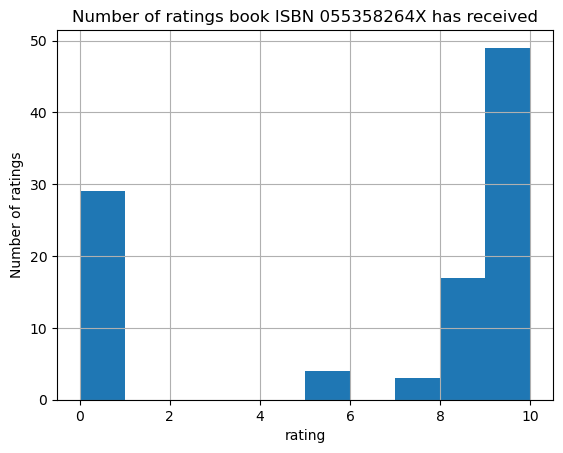

In [33]:
df_new.loc[df_new['ISBN'] == book]['bookRating'].hist()
plt.xlabel('rating')
plt.ylabel('Number of ratings')
plt.title('Number of ratings book ISBN 055358264X has received')
plt.show()

Ejemplo extraído de [acá](https://github.com/susanli2016/Machine-Learning-with-Python/blob/master/Building%20Recommender%20System%20with%20Surprise.ipynb)

## Referencias:

 * [Documentación de Surprise](https://surpriselib.com/)